# How Can Nonprofits Use AI to Personalize Something To Increase Donor Retention

In [1]:
import pandas as pd
import matplotlib.pyplot as pyplot
import numpy as np
import seaborn as sns
import scipy as sp

In [2]:
normalized_df = pd.read_csv('../ai_survey_normalized_clustering_data.csv')
survey_df = pd.read_csv('../ai_survey_results_2024_n=930.csv')

In [3]:
normalized_df.head()

,Unnamed: 0,nonprofit,org_years,regionality,org_small_med_large,global_north_south_int,collects_data,tech_person,merl_person,cloud_storage,...,[W] Generat,[W] Interpret,[W] Organi,[W] Predict,[W] Translat,[W] Other,[W] We don't know yet!,cluster3,cluster2,ai_want_2+
0,0,1.0,0.560000,0.25,1.0,0.0,1.0,0.0,0.0,1.0,...,0,0,1,1,0,0,0,1,1,1
1,1,1.0,0.046667,0.25,0.0,0.0,1.0,0.0,0.0,1.0,...,1,1,1,1,1,1,0,0,0,1
2,2,1.0,0.226667,0.25,0.0,0.0,1.0,1.0,0.0,1.0,...,0,1,0,0,1,0,0,-1,0,1
3,3,1.0,0.166667,0.50,0.0,0.0,1.0,1.0,1.0,1.0,...,0,1,1,1,0,0,0,1,1,1
4,4,1.0,0.053333,0.50,0.0,0.0,1.0,0.0,0.0,1.0,...,1,1,1,1,1,0,0,0,0,1


In [4]:
survey_df.head()

,Unnamed: 0,source,Start time,nonprofit,non_org_type,role,person_org_years,org_size,org_years,continent,...,global_north_south_int,org_size_int,hubs_rural_urban_int,af_region_int,india_rural_urban_int,collab_feasibility_raw,person_ai_comfort_raw,org_years_raw,person_org_years_raw,cluster3
0,0,The big one,2024-03-07 11:03:50,1.0,NaN,Fundraiser,0.066667,31-60,0.560000,North America,...,0.0,5.0,NaN,NaN,NaN,7.0,7.0,84.0,4.0,1
1,1,The big one,2024-03-07 11:03:03,1.0,NaN,Leader,0.116667,0-5,0.046667,North America,...,0.0,0.0,NaN,NaN,NaN,4.0,5.0,7.0,7.0,0
2,2,The big one,2024-03-07 11:05:30,1.0,NaN,Leader,0.016667,6-15,0.226667,North America,...,0.0,1.0,NaN,NaN,NaN,3.0,10.0,34.0,1.0,-1
3,3,The big one,2024-03-07 11:05:30,1.0,NaN,Comms,0.133333,6-15,0.166667,North America,...,0.0,1.0,NaN,NaN,NaN,8.0,10.0,25.0,8.0,1
4,4,The big one,2024-03-07 11:07:06,1.0,NaN,Leader,0.133333,0-5,0.053333,North America,...,0.0,0.0,NaN,NaN,NaN,4.0,0.0,8.0,8.0,0


## Step 0: Data Cleaning

In [5]:
# Drop non_org_type (96% null) and strip whitespace across all string columns
survey_df = survey_df.drop(columns=['non_org_type'])

for col in survey_df.select_dtypes(include='object').columns:
    survey_df[col] = survey_df[col].str.strip()

/var/folders/wj/f5mwndv501bc3llhjvlrdcz80000gn/T/ipykernel_22839/1013878781.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in survey_df.select_dtypes(include='object').columns:


In [6]:
import ast

LIST_COLS = ['ai_use', 'ai_want', 'ai_risk', 'data_kinds']

def parse_list_col(val):
    if pd.isna(val):
        return []
    # replace non-breaking spaces before parsing
    val = val.replace('\xa0', ' ')
    try:
        items = ast.literal_eval(val)
        return [s.strip() for s in items if isinstance(s, str) and s.strip()]
    except Exception:
        return [val.strip()] if val.strip() else []

for col in LIST_COLS:
    if col in survey_df.columns:
        survey_df[col] = survey_df[col].apply(parse_list_col)

In [7]:
# Drop rows where org_opentext is too short to be usable (< 5 chars)
survey_df = survey_df[
    survey_df['org_opentext'].isna() | (survey_df['org_opentext'].str.len() >= 5)
].reset_index(drop=True)

In [8]:
# Impute person_ai_comfort_raw from normalized person_ai_comfort (scale: 0–10)
mask = survey_df['person_ai_comfort_raw'].isna() & survey_df['person_ai_comfort'].notna()
survey_df.loc[mask, 'person_ai_comfort_raw'] = (survey_df.loc[mask, 'person_ai_comfort'] * 10).round()

In [9]:
# Fill missing region values with 'Unknown'
survey_df['continent'] = survey_df['continent'].fillna('Unknown')
survey_df['global_north_south'] = survey_df['global_north_south'].fillna('Unknown')

In [10]:
# Merge survey and normalized datasets on index
merged_df = survey_df.merge(
    normalized_df,
    left_index=True,
    right_index=True,
    suffixes=('', '_norm')
)

print(f"survey_df: {survey_df.shape}, normalized_df: {normalized_df.shape}, merged_df: {merged_df.shape}")

survey_df: (906, 47), normalized_df: (930, 38), merged_df: (906, 85)


## Theme Classification: AI Sentiment (`ai_theme`)

In [11]:
THEME_KEYWORDS = {
    'Privacy & Data Security': [
        'breach', 'privacy', 'data security', 'confidential', 'sensitive',
        'secure', 'protection', 'hack', 'leak', 'exposure', 'personal data'
    ],
    'Bias & Equity': [
        'bias', 'biased', 'inequit', 'discriminat', 'marginalized',
        'harm', 'unfair', 'equity', 'justice', 'oppress', 'disparity'
    ],
    'Over-reliance / Loss of Human Touch': [
        'human touch', 'relationship', 'authentic', 'replace', 'dependency',
        'over-reliance', 'creative', 'connection', 'dehumaniz', 'not thinking',
        'replacing workers', 'lose', 'personal touch'
    ],
    'Cost & Access': [
        'cost', 'afford', 'access', 'expensive', 'budget', 'resource',
        'capacity', 'barrier', 'limited', 'training', 'no experience',
        'understanding', 'small org', 'inequal'
    ],
    'Efficiency & Automation': [
        'efficien', 'automat', 'repetitive', 'time', 'scale', 'workflow',
        'productiv', 'streamline', 'save', 'fast', 'quick', 'leads',
        'trends', 'patterns', 'qualifying'
    ],
    'Content & Communication': [
        'content', 'writing', 'translat', 'generat', 'outreach',
        'communication', 'donor', 'message', 'email', 'letter', 'draft',
        'marketing', 'script', 'social media'
    ],
    'Ethics & Accountability': [
        'plagiar', 'copyright', 'intellectual property', 'accountab',
        'responsible', 'ethical', 'ethics', 'transparency', 'govern',
        'immoral', 'greedy', 'mishandl', 'unethical', 'environmental'
    ],
}

RISK_TO_THEME = {
    'Decisions based on biased AI models': 'Bias & Equity',
    'AI-related data breaches': 'Privacy & Data Security',
    'Plagiarism, violating copyrights': 'Ethics & Accountability',
    'Increasing inequity': 'Bias & Equity',
    '(Over) Dependency on commercial AI products': 'Over-reliance / Loss of Human Touch',
    'Replacing workers': 'Over-reliance / Loss of Human Touch',
    'Environmental impact': 'Ethics & Accountability',
}

WANT_TO_THEME = {
    'Generat': 'Content & Communication',
    'Translat': 'Content & Communication',
    'Ask': 'Content & Communication',
    'Assist': 'Efficiency & Automation',
    'Interpret': 'Efficiency & Automation',
    'Predict': 'Efficiency & Automation',
    'Organi': 'Efficiency & Automation',
}

In [12]:
def classify_from_text(text):
    if pd.isna(text) or not str(text).strip():
        return None
    text_lower = text.lower()
    scores = {theme: 0 for theme in THEME_KEYWORDS}
    for theme, keywords in THEME_KEYWORDS.items():
        for kw in keywords:
            if kw in text_lower:
                scores[theme] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else None

def classify_from_risk(risk_list):
    if not risk_list:
        return None
    for risk in risk_list:
        for key, theme in RISK_TO_THEME.items():
            if key.lower() in risk.lower():
                return theme
    return None

def classify_from_want(want_list):
    if not want_list:
        return None
    for want in want_list:
        for key, theme in WANT_TO_THEME.items():
            if key.lower() in want.lower():
                return theme
    return None

# Step 1: classify from ai_opentext free text
survey_df['ai_theme'] = survey_df['ai_opentext'].apply(classify_from_text)

# Step 2: fill nulls using ai_risk (already parsed lists)
mask = survey_df['ai_theme'].isna()
survey_df.loc[mask, 'ai_theme'] = survey_df.loc[mask, 'ai_risk'].apply(classify_from_risk)

# Step 3: fill remaining nulls using ai_want
mask = survey_df['ai_theme'].isna()
survey_df.loc[mask, 'ai_theme'] = survey_df.loc[mask, 'ai_want'].apply(classify_from_want)

print(f"After text + risk + want: {survey_df['ai_theme'].isna().sum()} nulls remaining")

After text + risk + want: 34 nulls remaining


In [13]:
from sklearn.neighbors import KNeighborsClassifier

# KNN fallback for any remaining nulls
KNN_FEATURES = ['cluster3', 'org_size_int', 'global_north_south_int', 'tech_person', 'merl_person', 'person_ai_comfort']

train = survey_df[survey_df['ai_theme'].notna()].copy()
test = survey_df[survey_df['ai_theme'].isna()].copy()

if len(test) > 0:
    X_train = train[KNN_FEATURES].fillna(0)
    X_test = test[KNN_FEATURES].fillna(0)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, train['ai_theme'])
    survey_df.loc[survey_df['ai_theme'].isna(), 'ai_theme'] = knn.predict(X_test)

print(f"Null remaining: {survey_df['ai_theme'].isna().sum()}")
print("\nTheme distribution:")
print(survey_df['ai_theme'].value_counts())

Null remaining: 0

Theme distribution:
ai_theme
Bias & Equity                          330
Privacy & Data Security                156
Efficiency & Automation                 94
Over-reliance / Loss of Human Touch     91
Ethics & Accountability                 88
Content & Communication                 84
Cost & Access                           63
Name: count, dtype: int64


## Step 0: EDA — Who Is In This Dataset?

In [ ]:
# Shared cluster color palette — define once, use everywhere
CLUSTER_PALETTE = {
    1:  '#2196F3',   # AI Consumers — blue
    0:  '#FFC107',   # Late Adopters — amber
    -1: '#F44336',   # AI Skeptics — red
}
CLUSTER_LABELS = {
    1:  'AI Consumers',
    0:  'Late Adopters',
    -1: 'AI Skeptics',
}

ORG_SIZE_ORDER = ['0-5', '6-15', '16-30', '31-60', '61-120', '121+']

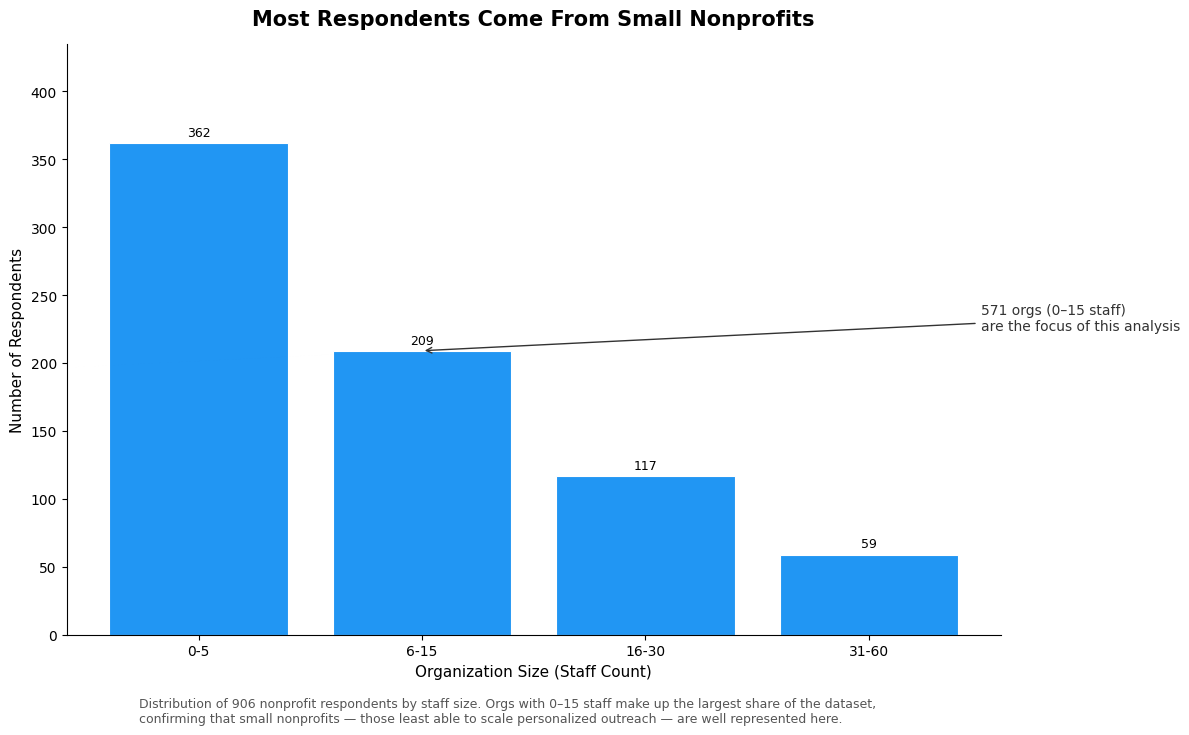

In [15]:
# Chart 1: Most Respondents Come From Small Nonprofits
size_counts = (
    survey_df['org_size']
    .value_counts()
    .reindex([s for s in ORG_SIZE_ORDER if s in survey_df['org_size'].values])
)

fig, ax = pyplot.subplots(figsize=(12, 7))
bars = ax.bar(size_counts.index, size_counts.values, color='#2196F3', edgecolor='white', linewidth=0.8)

# Annotation: highlight the two smallest bands
small_total = size_counts[['0-5', '6-15']].sum()
ax.annotate(
    f'{small_total} orgs (0–15 staff)\nare the focus of this analysis',
    xy=(1, size_counts['6-15']),
    xytext=(3.5, size_counts['6-15'] + 15),
    arrowprops=dict(arrowstyle='->', color='#333'),
    fontsize=10, color='#333'
)

ax.set_title('Most Respondents Come From Small Nonprofits', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Organization Size (Staff Count)', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_ylim(0, size_counts.max() * 1.2)
sns.despine()

pyplot.figtext(0.12, -0.04,
    'Distribution of 906 nonprofit respondents by staff size. '
    'Orgs with 0–15 staff make up the largest share of the dataset,\n'
    'confirming that small nonprofits — those least able to scale personalized outreach — are well represented here.',
    fontsize=9, color='#555')

pyplot.tight_layout()
pyplot.show()

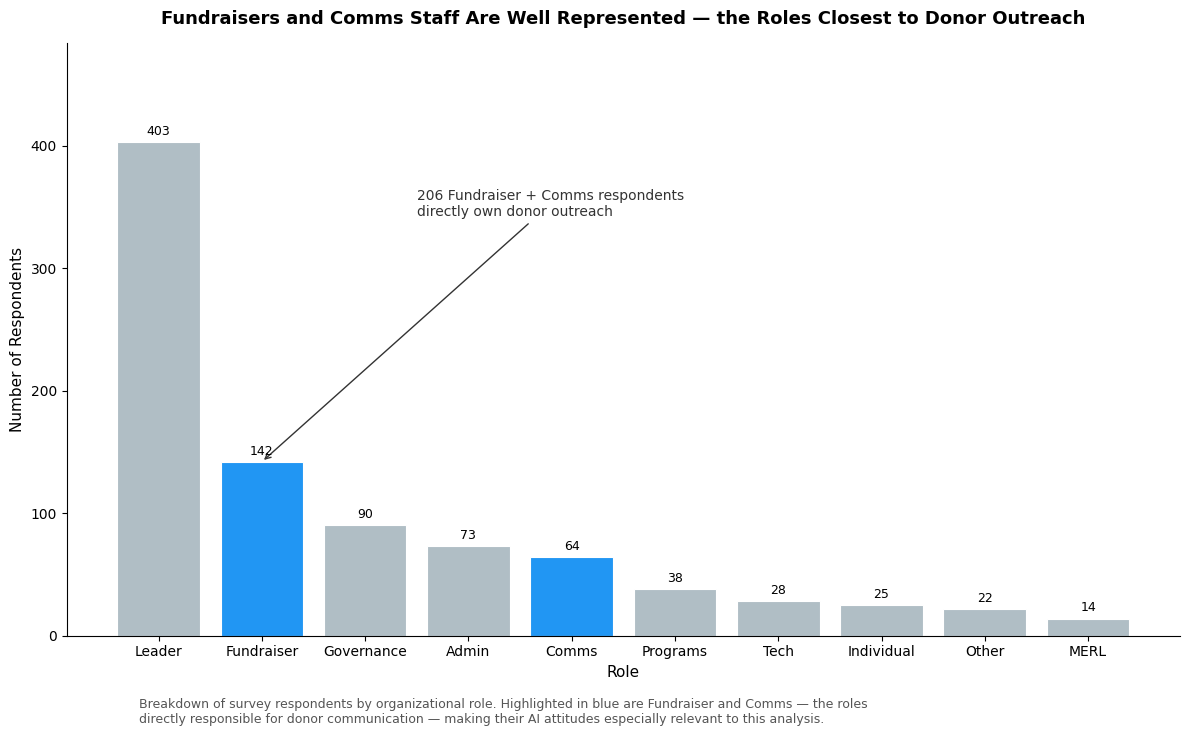

In [16]:
# Chart 2: Fundraisers and Leaders Dominate — the Roles Closest to Donor Outreach
role_counts = survey_df['role'].value_counts()

fig, ax = pyplot.subplots(figsize=(12, 7))
colors = ['#2196F3' if r in ['Fundraiser', 'Comms'] else '#B0BEC5' for r in role_counts.index]
bars = ax.bar(role_counts.index, role_counts.values, color=colors, edgecolor='white', linewidth=0.8)

# Annotation: call out donor-outreach roles
outreach_total = role_counts[role_counts.index.isin(['Fundraiser', 'Comms'])].sum()
ax.annotate(
    f'{outreach_total} Fundraiser + Comms respondents\ndirectly own donor outreach',
    xy=(role_counts.index.get_loc('Fundraiser'), role_counts['Fundraiser']),
    xytext=(2.5, role_counts.max() * 0.85),
    arrowprops=dict(arrowstyle='->', color='#333'),
    fontsize=10, color='#333'
)

ax.set_title('Fundraisers and Comms Staff Are Well Represented — the Roles Closest to Donor Outreach', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Role', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_ylim(0, role_counts.max() * 1.2)
sns.despine()

pyplot.figtext(0.12, -0.04,
    'Breakdown of survey respondents by organizational role. '
    'Highlighted in blue are Fundraiser and Comms — the roles\n'
    'directly responsible for donor communication — making their AI attitudes especially relevant to this analysis.',
    fontsize=9, color='#555')

pyplot.tight_layout()
pyplot.show()

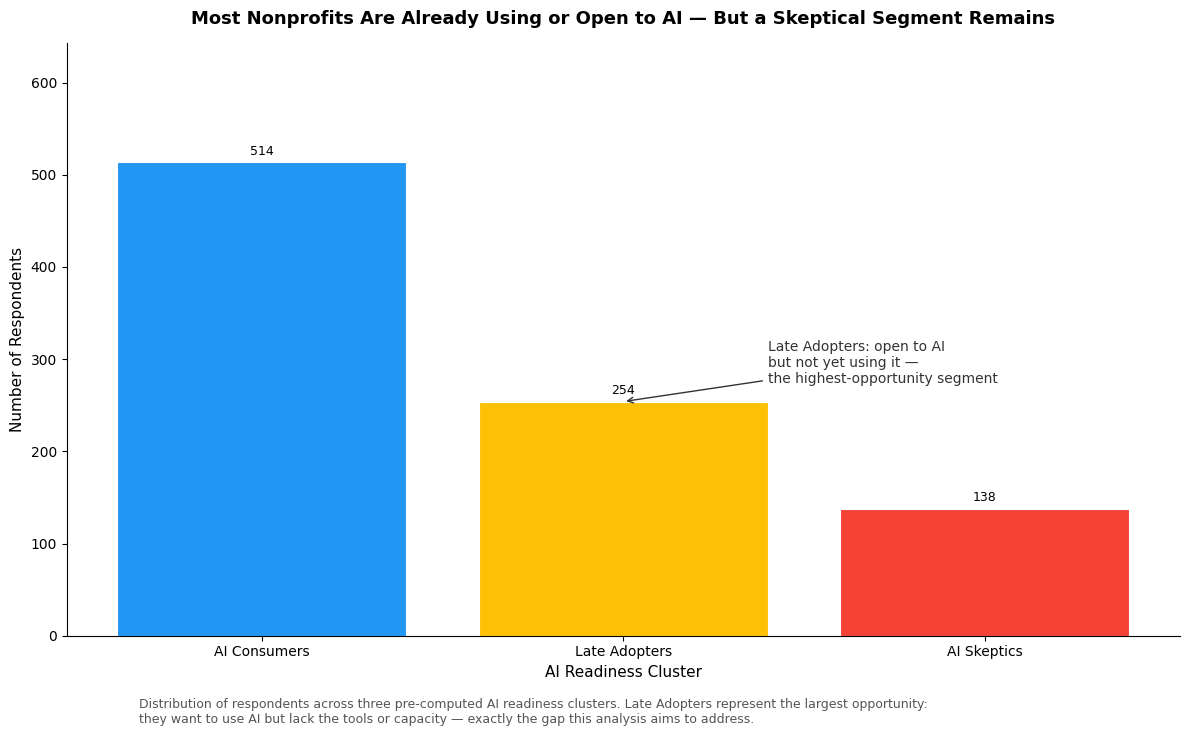

In [17]:
# Chart 3: Most Nonprofits Are Already Using or Open to AI — But a Skeptical Segment Remains
cluster_counts = survey_df['cluster3'].map(CLUSTER_LABELS).value_counts()
cluster_order = ['AI Consumers', 'Late Adopters', 'AI Skeptics']
cluster_counts = cluster_counts.reindex(cluster_order)
bar_colors = [CLUSTER_PALETTE[k] for k in [1, 0, -1]]

fig, ax = pyplot.subplots(figsize=(12, 7))
bars = ax.bar(cluster_counts.index, cluster_counts.values, color=bar_colors, edgecolor='white', linewidth=0.8)

# Annotation: Late Adopters are the key opportunity segment
ax.annotate(
    'Late Adopters: open to AI\nbut not yet using it —\nthe highest-opportunity segment',
    xy=(1, cluster_counts['Late Adopters']),
    xytext=(1.4, cluster_counts['Late Adopters'] + 20),
    arrowprops=dict(arrowstyle='->', color='#333'),
    fontsize=10, color='#333'
)

ax.set_title('Most Nonprofits Are Already Using or Open to AI — But a Skeptical Segment Remains', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('AI Readiness Cluster', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_ylim(0, cluster_counts.max() * 1.25)
sns.despine()

pyplot.figtext(0.12, -0.04,
    'Distribution of respondents across three pre-computed AI readiness clusters. '
    'Late Adopters represent the largest opportunity:\n'
    'they want to use AI but lack the tools or capacity — exactly the gap this analysis aims to address.',
    fontsize=9, color='#555')

pyplot.tight_layout()
pyplot.show()

## Step 1: Capacity Gap 

/var/folders/wj/f5mwndv501bc3llhjvlrdcz80000gn/T/ipykernel_22839/2025061430.py:5: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  survey_df['org_size'] = pd.Categorical(survey_df['org_size'], categories=ORG_SIZE_ORDER, ordered=True)


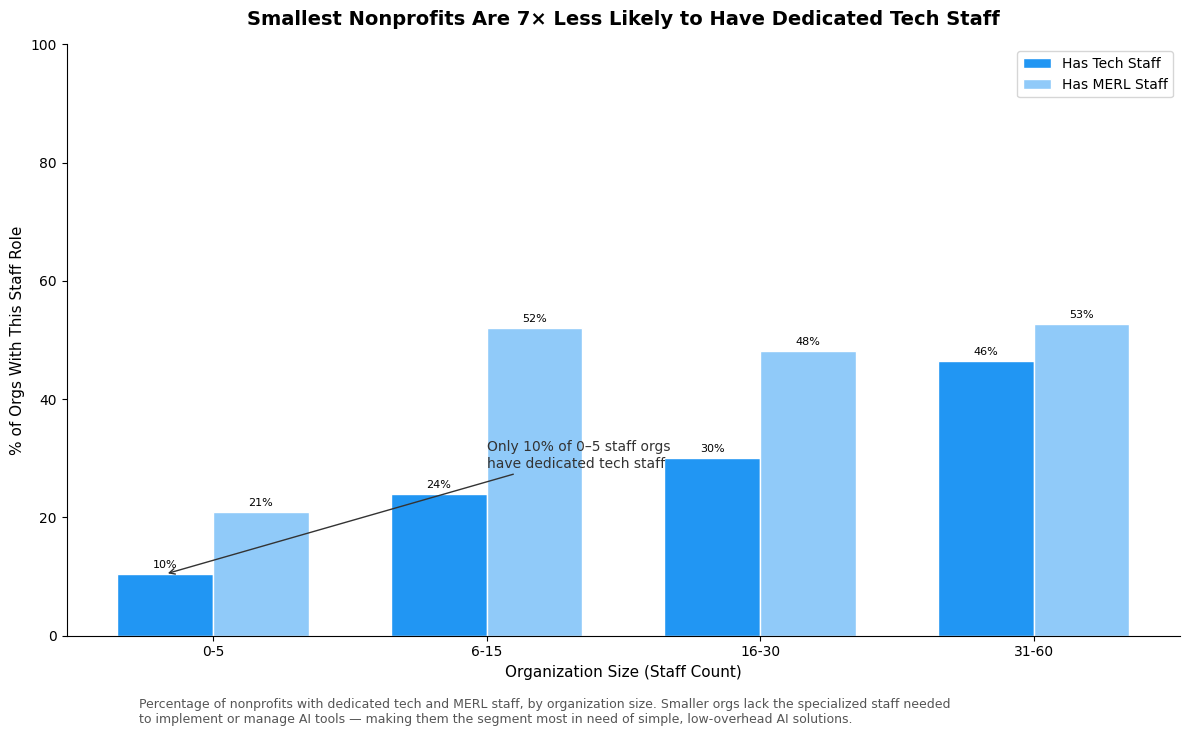

In [18]:
# Chart 4: Smallest Nonprofits Are 7x Less Likely to Have Dedicated Tech Staff
capacity_cols = ['tech_person', 'merl_person']
capacity_labels = {'tech_person': 'Has Tech Staff', 'merl_person': 'Has MERL Staff'}

survey_df['org_size'] = pd.Categorical(survey_df['org_size'], categories=ORG_SIZE_ORDER, ordered=True)
cap_rates = survey_df.groupby('org_size', observed=True)[capacity_cols].mean() * 100

x = np.arange(len(cap_rates))
width = 0.35

fig, ax = pyplot.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, cap_rates['tech_person'], width, label='Has Tech Staff', color='#2196F3', edgecolor='white')
bars2 = ax.bar(x + width/2, cap_rates['merl_person'], width, label='Has MERL Staff', color='#90CAF9', edgecolor='white')

# Annotation: callout the gap at smallest org size
ax.annotate(
    f"Only {cap_rates['tech_person'].iloc[0]:.0f}% of 0–5 staff orgs\nhave dedicated tech staff",
    xy=(x[0] - width/2, cap_rates['tech_person'].iloc[0]),
    xytext=(x[1], cap_rates['tech_person'].iloc[0] + 18),
    arrowprops=dict(arrowstyle='->', color='#333'),
    fontsize=10, color='#333'
)

ax.set_title("Smallest Nonprofits Are 7× Less Likely to Have Dedicated Tech Staff", fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Organization Size (Staff Count)', fontsize=11)
ax.set_ylabel('% of Orgs With This Staff Role', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(cap_rates.index)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.bar_label(bars1, fmt='%.0f%%', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.0f%%', padding=3, fontsize=8)
sns.despine()

pyplot.figtext(0.12, -0.04,
    'Percentage of nonprofits with dedicated tech and MERL staff, by organization size. '
    'Smaller orgs lack the specialized staff needed\n'
    'to implement or manage AI tools — making them the segment most in need of simple, low-overhead AI solutions.',
    fontsize=9, color='#555')

pyplot.tight_layout()
pyplot.show()

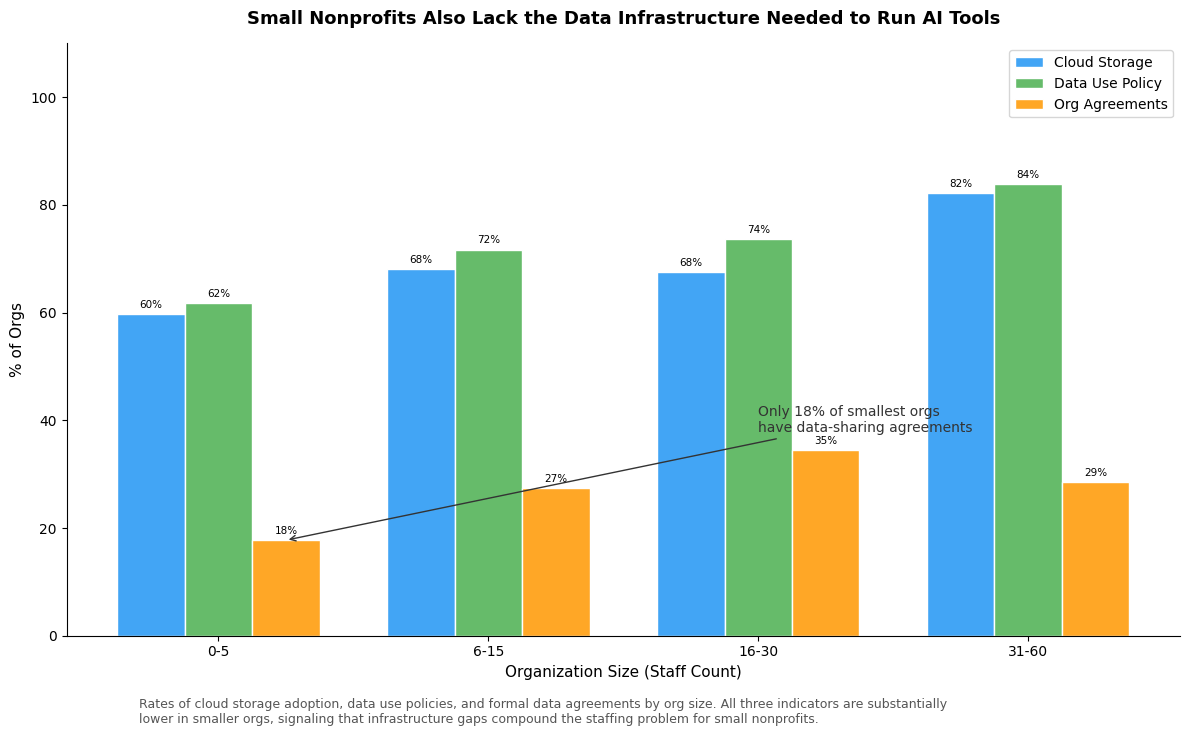

In [19]:
# Chart 5: Infrastructure Gaps Follow the Same Pattern as Staffing
infra_cols = ['cloud_storage', 'data_use_policy', 'org_agreements']
infra_labels = ['Cloud Storage', 'Data Use Policy', 'Org Agreements']
infra_colors = ['#42A5F5', '#66BB6A', '#FFA726']

infra_rates = survey_df.groupby('org_size', observed=True)[infra_cols].mean() * 100

x = np.arange(len(infra_rates))
width = 0.25

fig, ax = pyplot.subplots(figsize=(12, 7))
for i, (col, label, color) in enumerate(zip(infra_cols, infra_labels, infra_colors)):
    bars = ax.bar(x + (i - 1) * width, infra_rates[col], width, label=label, color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%.0f%%', padding=3, fontsize=7.5)

# Annotation: org_agreements is the lowest and most telling
ax.annotate(
    f"Only {infra_rates['org_agreements'].iloc[0]:.0f}% of smallest orgs\nhave data-sharing agreements",
    xy=(x[0] + width, infra_rates['org_agreements'].iloc[0]),
    xytext=(x[2], infra_rates['org_agreements'].iloc[0] + 20),
    arrowprops=dict(arrowstyle='->', color='#333'),
    fontsize=10, color='#333'
)

ax.set_title("Small Nonprofits Also Lack the Data Infrastructure Needed to Run AI Tools", fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Organization Size (Staff Count)', fontsize=11)
ax.set_ylabel('% of Orgs', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(infra_rates.index)
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
sns.despine()

pyplot.figtext(0.12, -0.04,
    'Rates of cloud storage adoption, data use policies, and formal data agreements by org size. '
    'All three indicators are substantially\n'
    'lower in smaller orgs, signaling that infrastructure gaps compound the staffing problem for small nonprofits.',
    fontsize=9, color='#555')

pyplot.tight_layout()
pyplot.show()

In [20]:
# Capacity Profile Table
all_cap_cols = ['tech_person', 'merl_person', 'cloud_storage', 'data_use_policy', 'org_agreements']
col_labels = ['Tech Staff %', 'MERL Staff %', 'Cloud Storage %', 'Data Policy %', 'Org Agreements %']

profile = survey_df.groupby('org_size', observed=True)[all_cap_cols].mean() * 100
profile.columns = col_labels
profile['Composite Capacity Score'] = profile.mean(axis=1)
profile = profile.round(1)

print("Capacity Profile by Organization Size\n")
print(profile.to_string())
profile

Capacity Profile by Organization Size

          Tech Staff %  MERL Staff %  Cloud Storage %  Data Policy %  Org Agreements %  Composite Capacity Score
org_size                                                                                                        
0-5               10.4          21.0             59.7           61.8              17.7                      34.1
6-15              23.9          52.0             68.1           71.7              27.5                      48.6
16-30             30.0          48.2             67.6           73.6              34.5                      50.8
31-60             46.4          52.7             82.1           83.9              28.6                      58.8


,Tech Staff %,MERL Staff %,Cloud Storage %,Data Policy %,Org Agreements %,Composite Capacity Score
org_size,,,,,,
0-5,10.4,21.0,59.7,61.8,17.7,34.1
6-15,23.9,52.0,68.1,71.7,27.5,48.6
16-30,30.0,48.2,67.6,73.6,34.5,50.8
31-60,46.4,52.7,82.1,83.9,28.6,58.8
